In [37]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import torchvision
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

## PART 1: Raytracer

In [9]:
RED=np.array([1.0, 0.0, 0.0])
GREEN=np.array([0.0, 1.0, 0.0])
BLUE=np.array([0.0, 0.0, 1.0])
WHITE=np.array([1.0, 1.0, 1.0])

In [10]:
class Sphere():
    def __init__(self, center, color, r=None):
        self.c = np.asarray(center)
        self.color = np.asarray(color)
        self.r = r

    # adapted from jamesbowman/raytrace
    def intersect(self, origin, direction):
        if self.r is None:
            f = 1.0 - origin[2]
            z = self.c[2] - origin[2]
            r = 0.05 * z / f
        else:
            r = self.r
        
        b = 2 * np.dot(direction, (origin - self.c))
        c1 = self.c @ self.c
        c2 = origin @ origin
        c3 = self.c @ origin
        c4 = r * r
        c = c1 + c2 - 2 * c3 - c4
        disc = b * b - 4 * c
        sq = np.sqrt(np.maximum(0, disc))
        h0 = (-b - sq) / 2
        h1 = (-b + sq) / 2
        h = np.where((h0 > 0) & (h0 < h1), h0, h1)
        pred = (disc > 0) & (h > 0)
        return np.where(pred, h, np.inf)

In [84]:
## Rendering
def raytrace(origin, direction, scene, bw=False):
    distances = np.array([s.intersect(origin, direction) for s in scene])
    nearest = np.min(distances, axis=0)

    if bw: color = np.zeros(direction.shape[0])
    else:  color = np.zeros((direction.shape[0], 3))  # R=0 G=0 B=0
        
    for (s, d) in zip(scene, distances):
        hit = (nearest != np.inf) & (d == nearest)
        color[hit] = 1 if bw else s.color
    return color

def render(scene, camera, w=128, h=128, step=0.1, frames=4, f=1.0, bw=False):
    r = float(w) / h
    screen = (-1, 1 / r + .25, 1, -1 / r + .25)
    x = np.tile(np.linspace(screen[0], screen[2], w), h)
    y = np.repeat(np.linspace(screen[1], screen[3], h), w)

    q = np.column_stack((x, y, np.full_like(x, f)))

    if bw: images = np.empty((frames, h, w))
    else:  images = np.empty((frames, h, w, 3))
    c = np.copy(camera)

    for i in range(frames):
        direction = q / np.linalg.norm(q, axis=1, keepdims=True)
        if bw:
            images[i] = raytrace(c, direction, scene, bw=bw).reshape(h, w)
        else:
            images[i] = raytrace(c, direction, scene, bw=bw).reshape(h, w, 3)
        c += np.array([0.0, 0.0, step])

    return images

def display(images):
    n_frames = images.shape[0]
    fig, axes = plt.subplots(
        1, n_frames,
        figsize=(3 * n_frames, 3.2),
        facecolor="#ffffff"
    )
    fig.subplots_adjust(wspace=0.04)
    
    if n_frames == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        ax.imshow(images[i])
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    
    plt.show()

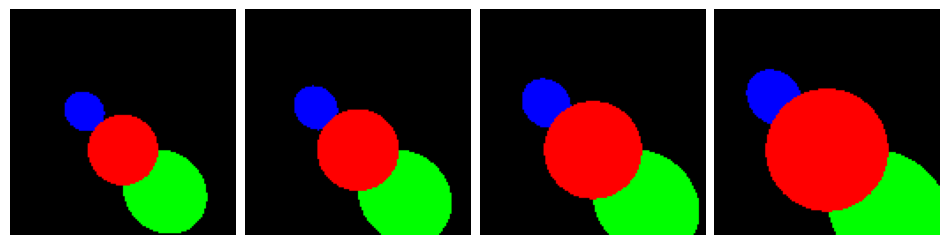

In [85]:
scene = [Sphere([0.0, 0.0, 2.0],  RED,   0.6),
         Sphere([1.0, -1.0, 3.0], GREEN, 1.0),
         Sphere([-1.0, 1.0, 3.0], BLUE,  0.5)]
camera = np.array([0.0, 0.0, 0.0])

images = render(scene, camera, step=0.25)
display(images)

## PART 2: Dataset

In [75]:
def dot_scene(distance, count=200, spread_xy=1.0, depth_jitter=1.0,
                   min_radius=0.01, max_radius=0.03):
    scene = []

    for _ in range(count):
        x = random.uniform(-spread_xy, spread_xy)
        y = random.uniform(-spread_xy, spread_xy)
        z = random.uniform(distance - depth_jitter, distance + depth_jitter)
        r = min_radius + (max_radius - min_radius) * (random.random() ** 2)
        scene.append(Sphere([x, y, z], WHITE, None))

    return scene

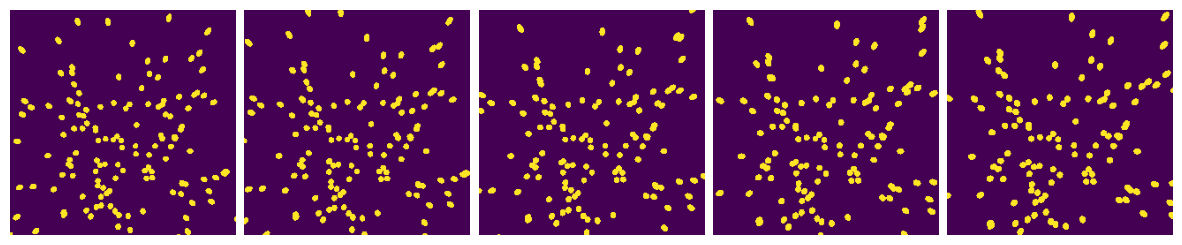

In [89]:
## Near scene
scene = dot_scene(0.0)
camera = np.array([0.0, 0.0, -1.0])

images = render(scene, camera, w=256, h=256, step=0.05, frames=5, bw=True)
display(images)

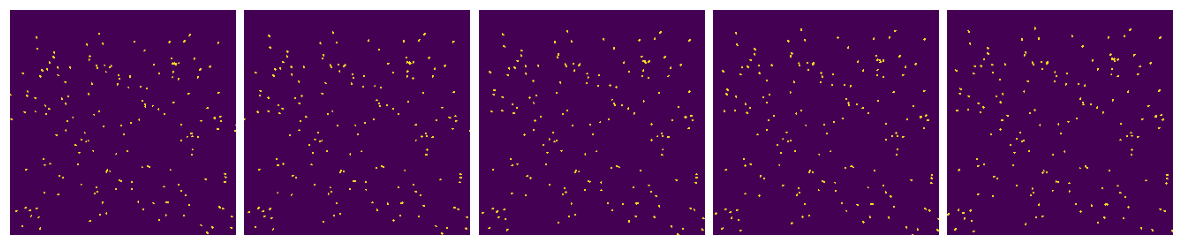

In [90]:
## Far scene
scene = dot_scene(0.0, spread_xy=5.0)
camera = np.array([0.0, 0.0, -5.0])

images = render(scene, camera, 256, 256, step=0.05, frames=5, bw=True)
display(images)

In [92]:
class SceneDataset(Dataset):
    def __init__(self, size):
        self.type = np.random.choice([0, 1], size=size)

    def __len__(self):
        return len(self.type)

    def __getitem__(self, idx):
        t = self.type[idx] 
        scene = dot_scene(0.0, spread_xy=5.0)
        if t == 0:
            camera = np.array([0.0, 0.0, -5.0])
        else:
            camera = np.array([0.0, 0.0, -1.0])
        
        out = render(scene, camera, 256, 256, step=0.05, frames=4, bw=True)
        return torch.Tensor(out), t

## PART 3: Waves

In [17]:
def make_coordinate_grid(grid_size):
    coords = np.arange(grid_size)
    return np.meshgrid(coords, coords, indexing="xy")

def normalize_frame(frame):
    frame = np.clip(frame, 0.0, None)
    max_val = frame.max()
    if max_val > 0:
        frame = frame / max_val
    return frame

def expanding_ring_sequence(
    grid_size=256,
    n_frames=4,
    noise_std=0.05,
    noise_mean=0.0,
    dr=None,
    clip=True
):
    if dr is None:
        dr = np.random.beta(1.5, 3.5) / 4
    
    xx, yy = make_coordinate_grid(grid_size)

    center = (grid_size - 1) / 2
    cx = center + np.random.uniform(-grid_size / 2, grid_size / 2)
    cy = center + np.random.uniform(-grid_size / 2, grid_size / 2)

    rr = np.hypot(xx - cx, yy - cy)
    r0 = np.random.uniform(grid_size / 12, grid_size / 4)
    width = np.random.uniform(grid_size / 12, grid_size / 10)

    rt = r0 + dr * grid_size * np.arange(n_frames)[:, None, None]
    frames = np.exp(-((rr - rt) ** 2) / (2 * width**2))

    frames = np.stack([normalize_frame(frame) for frame in frames], axis=0)

    noise = np.random.normal(loc=noise_mean, scale=noise_std, size=frames.shape)
    frames = frames + noise

    if clip:
        frames = np.clip(frames, 0.0, 1.0)

    return frames

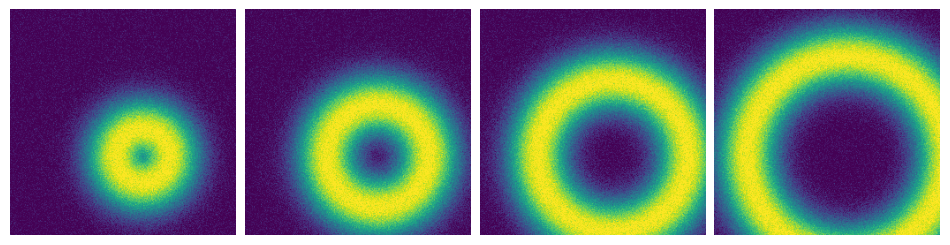

In [18]:
display(expanding_ring_sequence())

In [25]:
class RetinalWaveDataset(Dataset):
    def __init__(self, size):
        self.velocities = np.random.beta(1.5, 3.5, size=size)

    def __len__(self):
        return len(self.velocities)

    def __getitem__(self, idx):
        dr = self.velocities[idx]
        # generate two retinal waves of the same velocity
        return (torch.Tensor(expanding_ring_sequence(dr=dr)),
                torch.Tensor(expanding_ring_sequence(dr=dr)))

## PART 4: Pre-training

In [98]:
SIMCLR_EPOCHS = 10
SIMCLR_BATCH_SIZE = 64
SIMCLR_LR = 1e-3
SIMCLR_TEMPERATURE = 0.5
SIMCLR_LATENT = 32

device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device {device}")

Using device mps


### Model Definition

A lightly modified ResNet18.

In [100]:
from torchvision.models import resnet18

class Encoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()

        # no pretraining
        backbone = resnet18(weights=None)
        backbone.conv1 = nn.Conv2d(
            in_channels=4,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False,
        )

        self.backbone = nn.Sequential(*list(backbone.children())[:-1])  # -> [B, 512, 1, 1]
        self.head = nn.Linear(512, latent_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.backbone(x)         # [B, 512, 1, 1]
        x = torch.flatten(x, 1)      # [B, 512]
        z = self.head(x)             # [B, latent_dim]
        return z

### Loss function

In [101]:
def nt_xent_loss(z1, z2, temperature=0.5):
    """
    NT-Xent (Normalized Temperature-scaled Cross-Entropy) loss.

    Args:
        z1: (N, D) projected representations of first augmented views
        z2: (N, D) projected representations of second augmented views
        temperature: temperature scaling parameter tau

    Returns:
        Scalar loss (mean over all 2N positive pairs)
    """
    N = z1.shape[0]

    z1 = F.normalize(z1)
    z2 = F.normalize(z2)
    z = torch.concatenate([z1, z2], dim=0)

    sim = torch.div(z @ z.T, temperature)
    sim.fill_diagonal_(float("-inf"))

    sums = torch.logsumexp(sim, dim=0)
    
    upair = torch.diagonal(sim, offset=N)
    lpair = torch.diagonal(sim, offset=-N)
    loss = torch.cat([upair, lpair]) - sums
    
    return -torch.mean(loss)

### Training objective

In [102]:
def train_simclr(encoder, train_loader, epochs, lr, temperature, device):
    """
    Train SimCLR: encoder + projection head with NT-Xent loss.

    Args:
        encoder: SimCLREncoder instance
        proj_head: ProjectionHead instance
        train_loader: DataLoader yielding ((view1, view2), labels)
        epochs: number of training epochs
        lr: learning rate
        temperature: NT-Xent temperature
        device: torch device

    Returns:
        List of average loss per epoch
    """
    params = list(encoder.parameters())
    optimizer = optim.Adam(params, lr=lr)
    loss_history = []

    encoder.train()

    for epoch in range(epochs):
        total_loss = 0.0
        num_batches = 0

        for x1, x2 in train_loader:
            x1 = x1.to(device)
            x2 = x2.to(device)

            z1, z2 = encoder(x1), encoder(x2)

            loss = nt_xent_loss(z1, z2, temperature=temperature)

            optimizer.zero_grad()
            loss.backward()    
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        loss_history.append(avg_loss)
        print(f"  Epoch {epoch+1:2d}/{epochs}  loss={avg_loss:.4f}")

    return loss_history

In [108]:
torch.manual_seed(181)

train = RetinalWaveDataset(size=512)
loader = DataLoader(train, batch_size=SIMCLR_BATCH_SIZE, shuffle=True)
encoder = Encoder(SIMCLR_LATENT).to(device)

print("Retinal wave pre-training.")
losses = train_simclr(
    encoder, loader,
    epochs=SIMCLR_EPOCHS, lr=SIMCLR_LR,
    temperature=SIMCLR_TEMPERATURE, device=device
)


Retinal wave pre-training.
  Epoch  1/10  loss=4.0225
  Epoch  2/10  loss=3.7174
  Epoch  3/10  loss=3.6075
  Epoch  4/10  loss=3.5381
  Epoch  5/10  loss=3.5336
  Epoch  6/10  loss=3.4900
  Epoch  7/10  loss=3.4928
  Epoch  8/10  loss=3.4874
  Epoch  9/10  loss=3.4665
  Epoch 10/10  loss=3.4605


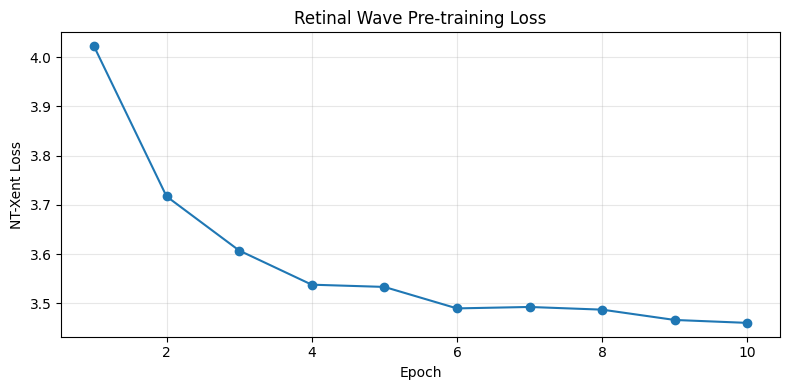

In [109]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(losses) + 1), losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("NT-Xent Loss")
plt.title("Retinal Wave Pre-training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## PART 5: Evaluation

In [113]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(SIMCLR_LATENT, 1)

    def forward(self, x):
        return self.linear(x)

In [119]:
def train_classifier(encoder, classifier, loader, epochs, lr, device):
    params = list(classifier.parameters())
    optimizer = optim.Adam(params, lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    loss_history = []

    encoder.eval()
    classifier.train()

    for epoch in range(epochs):
        total_loss = 0.0
        num_batches = 0

        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            z = encoder(x)

            logits = classifier(z)
            loss = criterion(logits, y.float().unsqueeze(1)) 

            optimizer.zero_grad()
            loss.backward()    
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        loss_history.append(avg_loss)
        print(f"  Epoch {epoch+1:2d}/{epochs}  loss={avg_loss:.4f}")

    return loss_history

In [120]:
torch.manual_seed(181)

train = SceneDataset(size=512)
loader = DataLoader(train, batch_size=SIMCLR_BATCH_SIZE, shuffle=True)
classifier = Classifier().to(device)

# uses the encoder from earlier
print("Pre-trained classifier.")
losses = train_classifier(
    encoder, classifier, loader,
    epochs=SIMCLR_EPOCHS, lr=SIMCLR_LR,
    device=device
)

Pre-trained classifier.
  Epoch  1/10  loss=0.7607
  Epoch  2/10  loss=0.7360
  Epoch  3/10  loss=0.7117
  Epoch  4/10  loss=0.6919
  Epoch  5/10  loss=0.6738
  Epoch  6/10  loss=0.6579
  Epoch  7/10  loss=0.6432
  Epoch  8/10  loss=0.6254
  Epoch  9/10  loss=0.6083
  Epoch 10/10  loss=0.5941
